# Edge Detection Filters

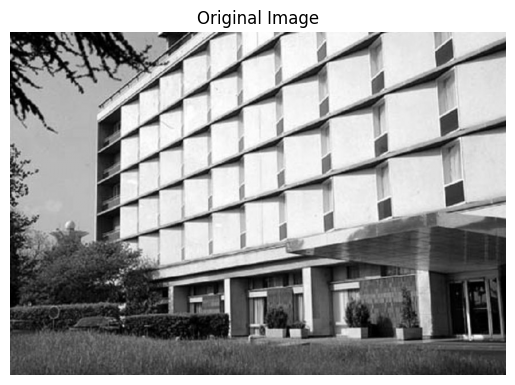

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = r"building.jpg"

img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
assert img is not None, "Image not found - check IMAGE_PATH"

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

## Sobel Gradients (X, Y, Magnitude)

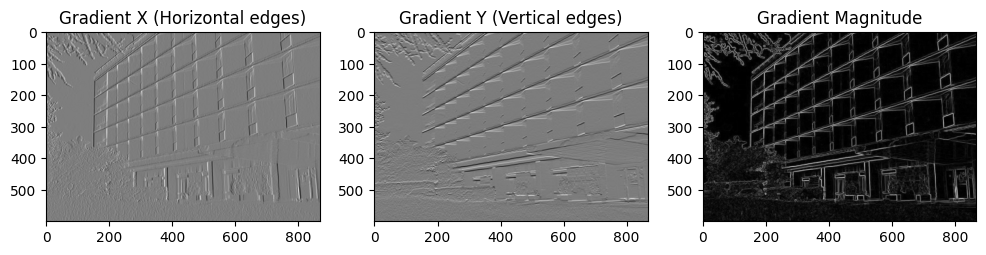

In [8]:
grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # horizontal derivative
grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # vertical derivative


magnitude = np.sqrt(grad_x**2 + grad_y**2)
orientation = np.arctan2(grad_y, grad_x) * 180 / np.pi

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(grad_x, cmap="gray"); plt.title("Gradient X (Horizontal edges)")
plt.subplot(1,3,2); plt.imshow(grad_y, cmap="gray"); plt.title("Gradient Y (Vertical edges)")
plt.subplot(1,3,3); plt.imshow(magnitude, cmap="gray"); plt.title("Gradient Magnitude")
plt.show()

## Laplacian

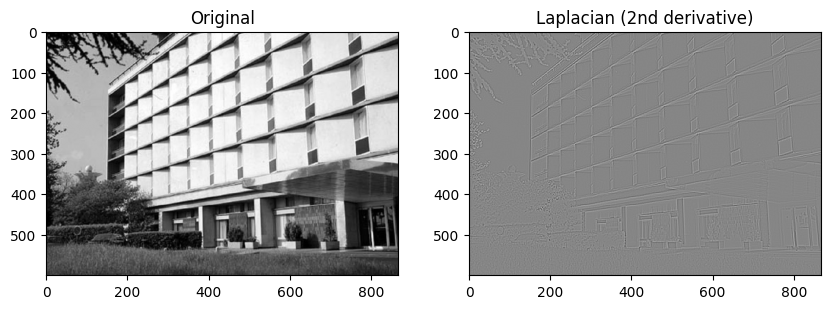

In [14]:
laplacian = cv2.Laplacian(img, cv2.CV_64F)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img, cmap="gray"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(laplacian, cmap="gray"); plt.title("Laplacian (2nd derivative)")
plt.show()

## Canny

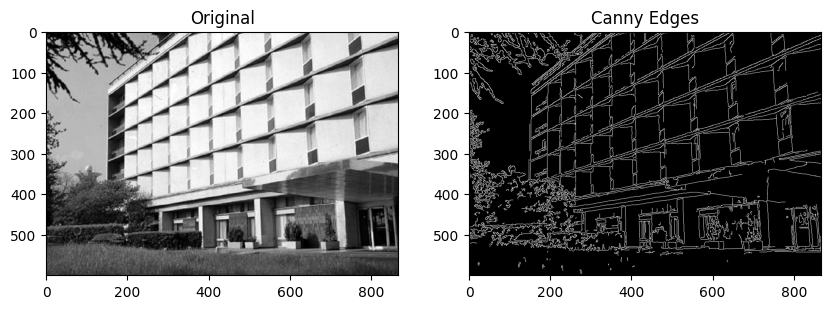

In [16]:
edges = cv2.Canny(img, 100, 200)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img, cmap="gray"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(edges, cmap="gray"); plt.title("Canny Edges")
plt.show()

## Roberts & Prewitt

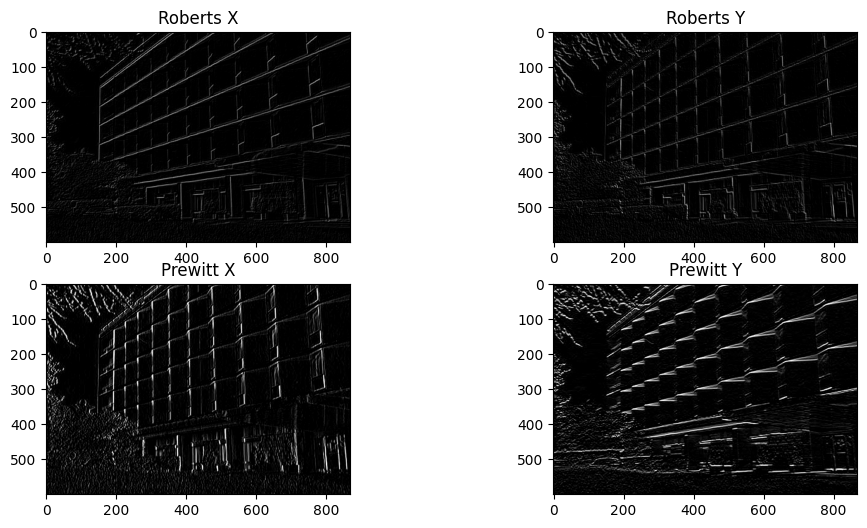

In [19]:
roberts_x = np.array([[1, 0], [0, -1]])
roberts_y = np.array([[0, 1], [-1, 0]])

prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

sobel_3x3x = cv2.getDerivKernels(1, 0, 3)[0]
sobel_3x3y = cv2.getDerivKernels(0, 1, 3)[0]

# Apply with cv2.filter2D
rob_x = cv2.filter2D(img, -1, roberts_x)
rob_y = cv2.filter2D(img, -1, roberts_y)
pre_x = cv2.filter2D(img, -1, prewitt_x)
pre_y = cv2.filter2D(img, -1, prewitt_y)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.imshow(rob_x, cmap="gray"); plt.title("Roberts X")
plt.subplot(2,2,2); plt.imshow(rob_y, cmap="gray"); plt.title("Roberts Y")
plt.subplot(2,2,3); plt.imshow(pre_x, cmap="gray"); plt.title("Prewitt X")
plt.subplot(2,2,4); plt.imshow(pre_y, cmap="gray"); plt.title("Prewitt Y")
plt.show()

## Sobel 3×3 vs 5×5

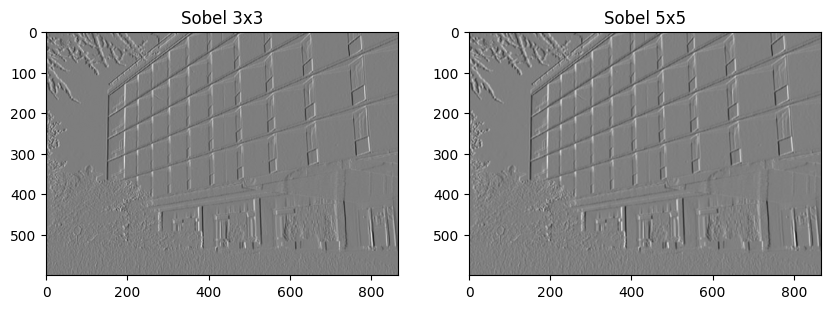

In [21]:
sobel3 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel5 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(sobel3, cmap="gray"); plt.title("Sobel 3x3")
plt.subplot(1,2,2); plt.imshow(sobel5, cmap="gray"); plt.title("Sobel 5x5")
plt.show()

## Gaussian, LoG & DoG

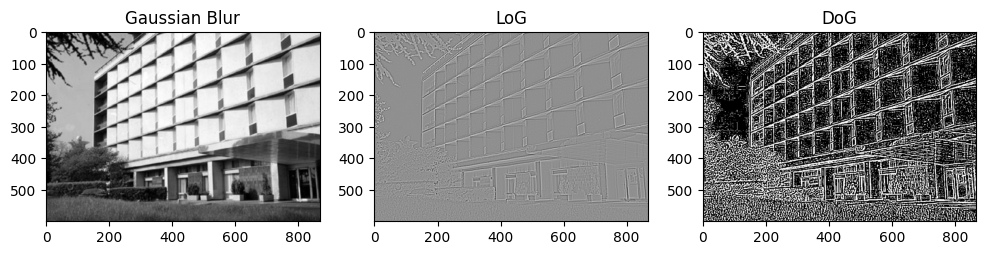

In [24]:
blur = cv2.GaussianBlur(img, (5,5), 1)

log = cv2.Laplacian(blur, cv2.CV_64F)

blur1 = cv2.GaussianBlur(img, (5,5), 1)
blur2 = cv2.GaussianBlur(img, (5,5), 2)
dog = blur1 - blur2

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(blur, cmap="gray"); plt.title("Gaussian Blur")
plt.subplot(1,3,2); plt.imshow(log, cmap="gray"); plt.title("LoG")
plt.subplot(1,3,3); plt.imshow(dog, cmap="gray"); plt.title("DoG")
plt.show()